In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

iris = load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names


## Visualization Function

In [2]:
def plot_kmeans_2d_boundaries(
    X2,
    y_true,
    k,
    ax=None,
    mesh_steps=400,
    random_state=42,
):
    """
    Plot K-Means decision boundaries in 2D.
    Points are colored by TRUE class labels.
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 5))

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X2)

    km = KMeans(n_clusters=k, random_state=random_state, n_init="auto")
    km.fit(X_scaled)

    # Create mesh grid
    x_min, x_max = X_scaled[:, 0].min() - 0.75, X_scaled[:, 0].max() + 0.75
    y_min, y_max = X_scaled[:, 1].min() - 0.75, X_scaled[:, 1].max() + 0.75

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, mesh_steps),
        np.linspace(y_min, y_max, mesh_steps),
    )

    Z = km.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # Plot cluster regions
    ax.contourf(xx, yy, Z, alpha=0.25)

    # Plot TRUE labels (3 classes)
    ax.scatter(
        X_scaled[:, 0],
        X_scaled[:, 1],
        c=y_true,
        s=35,
        edgecolor="k",
        linewidth=0.3,
    )

    ax.set_title(f"K-Means decision regions (k={k})")
    return ax


## Visualization: Petal Length vs Petal Width

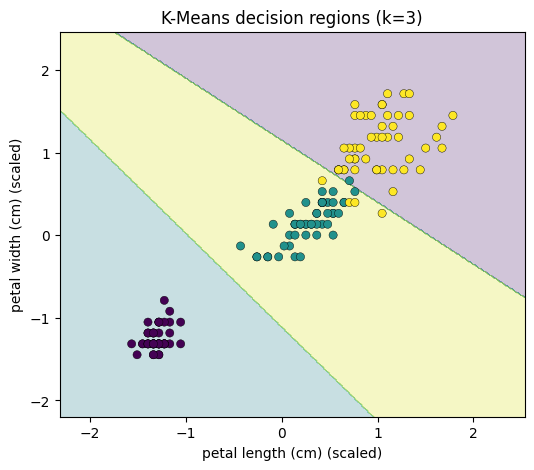

In [3]:
X_pw = X[:, [2, 3]]  # petal length, petal width

fig, ax = plt.subplots(figsize=(6, 5))
plot_kmeans_2d_boundaries(X_pw, y, k=3, ax=ax)
ax.set_xlabel(feature_names[2] + " (scaled)")
ax.set_ylabel(feature_names[3] + " (scaled)")
plt.show()


## Cluster Boundaries for k = 2 to 5

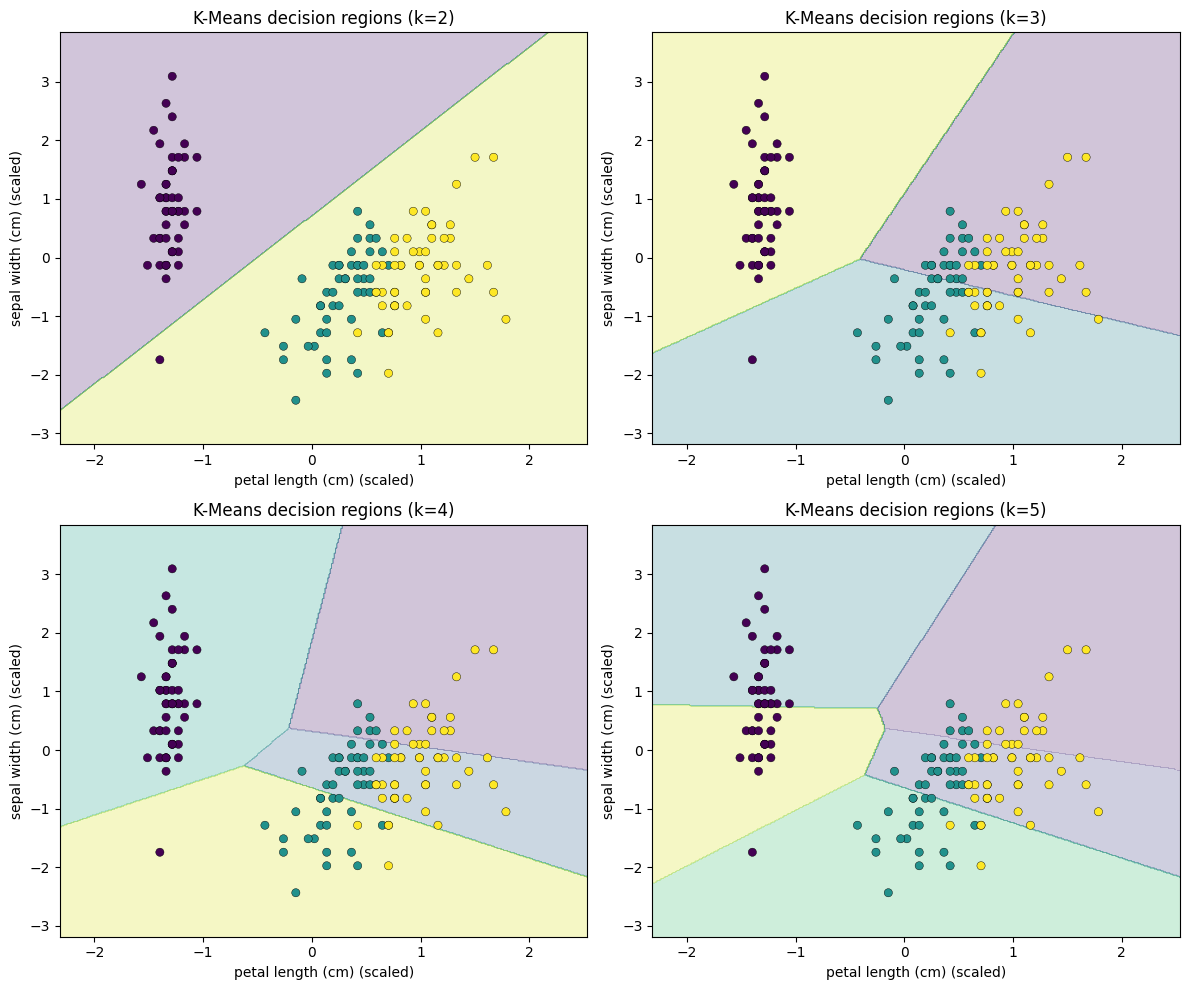

In [4]:
X_pl_sw = X[:, [2, 1]]  # petal length, sepal width

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

for ax, k in zip(axes, [2, 3, 4, 5]):
    plot_kmeans_2d_boundaries(X_pl_sw, y, k=k, ax=ax)
    ax.set_xlabel(feature_names[2] + " (scaled)")
    ax.set_ylabel(feature_names[1] + " (scaled)")

plt.tight_layout()
plt.show()


## Elbow and Silhouette Plots (k = 2 to 10)

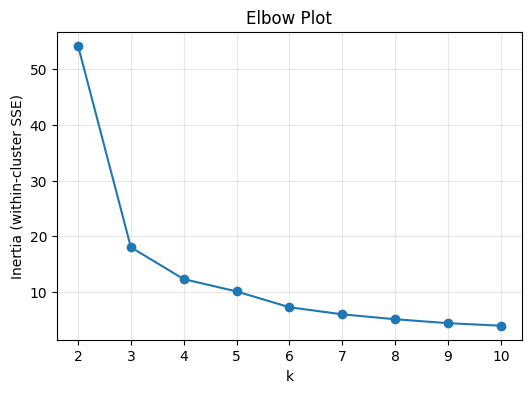

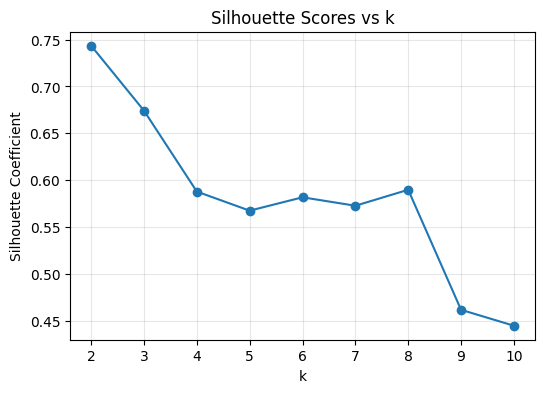

In [5]:
X_eval = X[:, [2, 3]]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_eval)

k_values = range(2, 11)
inertias = []
silhouettes = []

for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init="auto")
    km.fit(X_scaled)

    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, km.labels_))

# Elbow Plot
plt.figure(figsize=(6, 4))
plt.plot(list(k_values), inertias, marker="o")
plt.xlabel("k")
plt.ylabel("Inertia (within-cluster SSE)")
plt.title("Elbow Plot")
plt.grid(True, alpha=0.3)
plt.show()

# Silhouette Plot
plt.figure(figsize=(6, 4))
plt.plot(list(k_values), silhouettes, marker="o")
plt.xlabel("k")
plt.ylabel("Silhouette Coefficient")
plt.title("Silhouette Scores vs k")
plt.grid(True, alpha=0.3)
plt.show()
